In [77]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

In [41]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat  = tf.keras.utils.to_categorical(y_test, 10)

In [58]:
BATCH_SIZE = 16

def preprocess(image, label):
    image = tf.image.resize(image, (32, 32))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [43]:
bce_loss = tf.keras.losses.BinaryCrossentropy()

In [62]:
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        # Convert to float32 if integer
        if y_true.dtype != tf.float32:
            y_true = tf.cast(y_true, tf.float32)
        # Convert integer labels to one-hot if needed
        if len(y_true.shape) == 1:
            y_true = tf.one_hot(tf.cast(y_true, tf.int32), 10)
            y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(weight * ce)
    return loss

In [67]:
class ArcFaceLoss(tf.keras.losses.Loss):
    def __init__(self, s=30.0, m=0.50):
        super().__init__()
        self.s = s
        self.m = m

    def call(self, y_true, y_pred):
        # Squeeze if needed (shape: (batch, 1) -> (batch,))
        if len(y_true.shape) > 1 and y_true.shape[1] == 1:
            y_true = tf.squeeze(y_true, axis=1)
        # Convert to float32 if integer
        if y_true.dtype != tf.float32:
            y_true = tf.cast(y_true, tf.float32)
        # Convert integer labels to one-hot
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), 10)
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.nn.l2_normalize(y_pred, axis=1)
        cosine = y_pred
        theta = tf.acos(tf.clip_by_value(cosine, -1.0, 1.0))
        target_logits = tf.cos(theta + self.m)
        logits = cosine * (1 - y_true) + target_logits * y_true
        logits *= self.s
        return tf.keras.losses.categorical_crossentropy(y_true, logits, from_logits=True)

In [46]:
def alexnet():
    model = models.Sequential([
        layers.Conv2D(64, 3, activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [47]:
def vggnet():
    model = models.Sequential([
        layers.Conv2D(64, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [48]:
def resnet_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def resnet():
    inputs = layers.Input(shape=(32,32,3))
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    x = resnet_block(x, 64)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    return models.Model(inputs, outputs)

In [49]:
def train_model(model, optimizer, loss_fn, epochs):
    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=['accuracy']
    )

    history = model.fit(
        train_ds,
        epochs=epochs,
        batch_size=64,
        validation_data=test_ds,
        verbose=1
    )
    return history

In [59]:
vgg = vggnet()
hist_vgg = train_model(
    vgg,
    tf.keras.optimizers.Adam(),
    tf.keras.losses.SparseCategoricalCrossentropy(),
    epochs=10
)

Epoch 1/10
3125/3125 [==============================] - 15s 4ms/step - loss: 1.3574 - accuracy: 0.5104 - val_loss: 1.0837 - val_accuracy: 0.6167
Epoch 2/10
3125/3125 [==============================] - 14s 4ms/step - loss: 0.8991 - accuracy: 0.6822 - val_loss: 0.8916 - val_accuracy: 0.6928
Epoch 3/10
3125/3125 [==============================] - 14s 4ms/step - loss: 0.6993 - accuracy: 0.7537 - val_loss: 0.8722 - val_accuracy: 0.7072
Epoch 4/10
3125/3125 [==============================] - 14s 4ms/step - loss: 0.5433 - accuracy: 0.8078 - val_loss: 0.8172 - val_accuracy: 0.7423
Epoch 5/10
3125/3125 [==============================] - 14s 4ms/step - loss: 0.4194 - accuracy: 0.8523 - val_loss: 0.8797 - val_accuracy: 0.7301
Epoch 6/10
3125/3125 [==============================] - 13s 4ms/step - loss: 0.3126 - accuracy: 0.8896 - val_loss: 1.0932 - val_accuracy: 0.7188
Epoch 7/10
3125/3125 [==============================] - 13s 4ms/step - loss: 0.2359 - accuracy: 0.9164 - val_loss: 1.2537 - val_ac

In [74]:
test_loss, test_acc = vgg.evaluate(test_ds, verbose=0)
train_loss, train_acc = vgg.evaluate(train_ds, verbose=0)

print(f"VGG Test Accuracy: {test_acc*100:.2f}%")
print(f"VGG Test Loss: {test_loss:.4f}")
print(f"VGG Train Accuracy: {train_acc*100:.2f}%")
print(f"VGG Train Loss: {train_loss:.4f}")

VGG Test Accuracy: 73.02%
VGG Test Loss: 1.4213
VGG Train Accuracy: 97.27%
VGG Train Loss: 0.0819


In [63]:
alex = alexnet()
hist_alex = train_model(
    alex,
    tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    focal_loss(),
    epochs=20
)

Epoch 1/20
3125/3125 [==============================] - 12s 3ms/step - loss: 2.0983 - accuracy: 0.0982 - val_loss: 2.0983 - val_accuracy: 0.0920
Epoch 2/20
3125/3125 [==============================] - 11s 3ms/step - loss: 2.0983 - accuracy: 0.0953 - val_loss: 2.0983 - val_accuracy: 0.0930
Epoch 3/20
3125/3125 [==============================] - 10s 3ms/step - loss: 2.0982 - accuracy: 0.0940 - val_loss: 2.0982 - val_accuracy: 0.0973
Epoch 4/20
3125/3125 [==============================] - 13s 4ms/step - loss: 2.0982 - accuracy: 0.0965 - val_loss: 2.0982 - val_accuracy: 0.1016
Epoch 5/20
3125/3125 [==============================] - 13s 4ms/step - loss: 2.0982 - accuracy: 0.0980 - val_loss: 2.0982 - val_accuracy: 0.1049
Epoch 6/20
3125/3125 [==============================] - 14s 4ms/step - loss: 2.0982 - accuracy: 0.0980 - val_loss: 2.0982 - val_accuracy: 0.1007
Epoch 7/20
3125/3125 [==============================] - 13s 4ms/step - loss: 2.0982 - accuracy: 0.0968 - val_loss: 2.0982 - val_ac

In [75]:
test_loss, test_acc = alex.evaluate(test_ds, verbose=0)
train_loss, train_acc = alex.evaluate(train_ds, verbose=0)

print(f"AlexNet Test Accuracy: {test_acc*100:.2f}%")
print(f"AlexNet Test Loss: {test_loss:.4f}")
print(f"AlexNet Train Accuracy: {train_acc*100:.2f}%")
print(f"AlexNet Train Loss: {train_loss:.4f}")

AlexNet Test Accuracy: 11.00%
AlexNet Test Loss: 2.0982
AlexNet Train Accuracy: 10.56%
AlexNet Train Loss: 2.0982


In [68]:
res = resnet()
hist_res = train_model(
    res,
    tf.keras.optimizers.Adam(),
    ArcFaceLoss(),
    epochs=15
)

Epoch 1/15
3125/3125 [==============================] - 15s 5ms/step - loss: 15.8220 - accuracy: 0.3499 - val_loss: 14.7318 - val_accuracy: 0.4520
Epoch 2/15
3125/3125 [==============================] - 14s 4ms/step - loss: 14.0926 - accuracy: 0.4773 - val_loss: 13.4203 - val_accuracy: 0.5071
Epoch 3/15
3125/3125 [==============================] - 14s 4ms/step - loss: 13.0704 - accuracy: 0.5301 - val_loss: 12.5145 - val_accuracy: 0.5464
Epoch 4/15
3125/3125 [==============================] - 14s 4ms/step - loss: 12.3575 - accuracy: 0.5608 - val_loss: 12.2338 - val_accuracy: 0.5533
Epoch 5/15
3125/3125 [==============================] - 14s 4ms/step - loss: 11.8606 - accuracy: 0.5811 - val_loss: 11.8440 - val_accuracy: 0.5779
Epoch 6/15
3125/3125 [==============================] - 14s 4ms/step - loss: 11.4102 - accuracy: 0.6024 - val_loss: 11.3898 - val_accuracy: 0.5979
Epoch 7/15
3125/3125 [==============================] - 14s 4ms/step - loss: 11.0645 - accuracy: 0.6168 - val_loss: 10

In [76]:
test_loss, test_acc = res.evaluate(test_ds, verbose=0)
train_loss, train_acc = res.evaluate(train_ds, verbose=0)

print(f"ResNet Test Accuracy: {test_acc*100:.2f}%")
print(f"ResNet Test Loss: {test_loss:.4f}")
print(f"ResNet Train Accuracy: {train_acc*100:.2f}%")
print(f"ResNet Train Loss: {train_loss:.4f}")

ResNet Test Accuracy: 66.72%
ResNet Test Loss: 9.8493
ResNet Train Accuracy: 69.33%
ResNet Train Loss: 9.1692


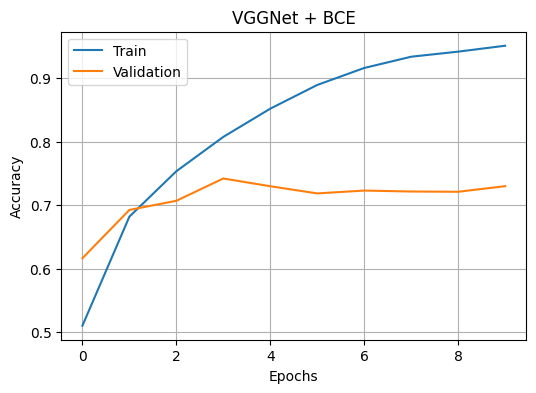

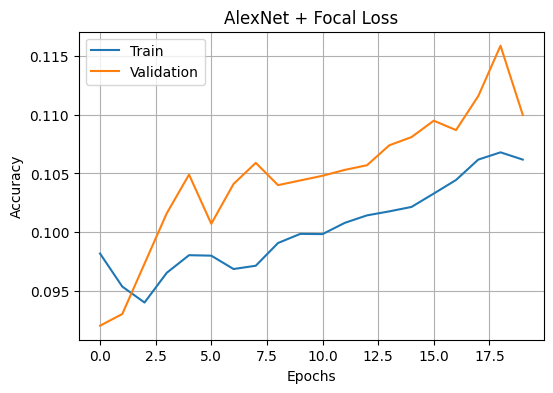

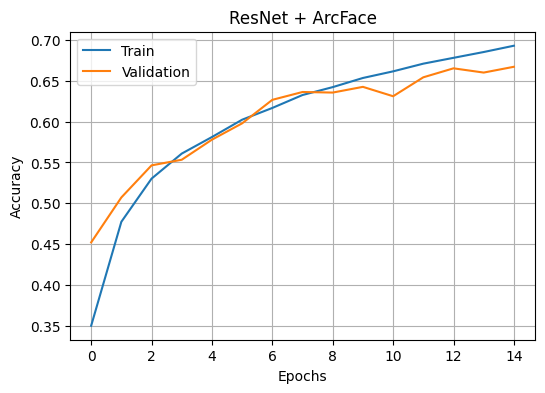

In [73]:
def plot_history(hist, title):
    plt.figure(figsize=(6,4))
    plt.plot(hist.history['accuracy'], label='Train')
    plt.plot(hist.history['val_accuracy'], label='Validation')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

plot_history(hist_vgg, "VGGNet + BCE")
plot_history(hist_alex, "AlexNet + Focal Loss")
plot_history(hist_res, "ResNet + ArcFace")

## Part 3

In [78]:
def build_feature_extractor(model):
    return tf.keras.Model(
        inputs=model.input,
        outputs=model.layers[-2].output  # layer before Dense(10)
    )

In [79]:
N = 2000  # t-SNE works best with small data
x_vis = x_test[:N]
y_vis = y_test[:N].flatten()

In [80]:
feature_model_bce = build_feature_extractor(vgg)
features_bce = feature_model_bce.predict(x_vis, batch_size=64)

32/32 [==============================] - 0s 12ms/step


In [81]:
feature_model_arc = build_feature_extractor(res)
features_arc = feature_model_arc.predict(x_vis, batch_size=64)

32/32 [==============================] - 0s 7ms/step


In [82]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

tsne_bce = tsne.fit_transform(features_bce)
tsne_arc = tsne.fit_transform(features_arc)

In [83]:
def plot_tsne(features, labels, title):
    plt.figure(figsize=(7,6))
    scatter = plt.scatter(
        features[:, 0],
        features[:, 1],
        c=labels,
        cmap='tab10',
        s=10
    )
    plt.legend(*scatter.legend_elements(), title="Classes", bbox_to_anchor=(1.05,1))
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(title)
    plt.grid(True)
    plt.show()

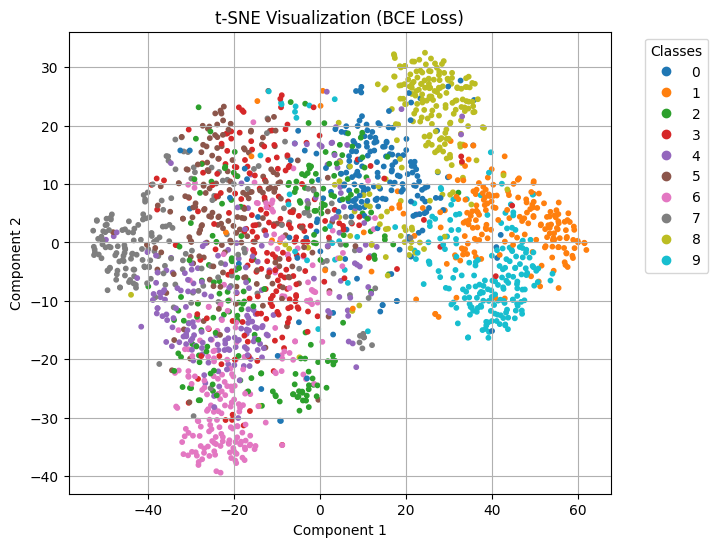

In [84]:
plot_tsne(tsne_bce, y_vis, "t-SNE Visualization (BCE Loss)")

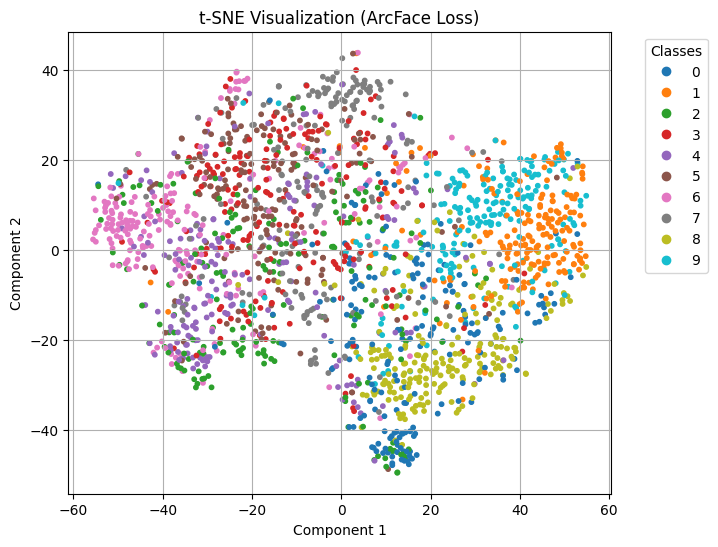

In [85]:
plot_tsne(tsne_arc, y_vis, "t-SNE Visualization (ArcFace Loss)")